# **LIMPIEZA DE DATOS**

## **0. CARGAR LAS LIBRERÍAS NECESARIAS Y DATOS ORIGINALES**

Cargar librerias desde el entorno Colab

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

El siguiente paso es cargar datos. Podemos cargar los datos desde una URL, o "subiendolos" al entorno de ejecución

 Es el nombre que le pusimos a nuestro dataset es `df`, pero puede ser cualquier otro

In [ ]:
# La base de datos puede cargarse desde una URL
url = 'https://github.com/estebangonzalezITM/DataScience/raw/main/MaterialdeEstudio/Semana7/titanic_train.csv'
df = pd.read_csv(url)
df.head()

In [197]:
# Alternativamente, la base de datos puede subirse a este entorno de ejecución
df = pd.read_csv('titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **1. INSPECCIÓN Y PERFILADO**

Información inicial del DataFrame y conteo de nulos:

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [199]:
# Conteno de valores nulos
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [200]:
df.duplicated().sum()

np.int64(0)

## **2. ELIMINACIÓN DE DUPLICADOS**

In [203]:
# df.drop_duplicates(inplace=True)

In [204]:
duplicates_before = df.duplicated().sum()                             # Esta línea cuenta las filas duplicadas tiene el dataset
if duplicates_before > 0:
    df.drop_duplicates(inplace=True)                                  # Esta línea elimina las filas duplicadas
    print(f"Se eliminaron {duplicates_before} registros duplicados.")
else:
    print("No se encontraron registros duplicados.")

No se encontraron registros duplicados.


## **3. MANEJO DE VALORES FALTANTES**

Mostramos solo las columnas con valores nulos para ser concisos

In [205]:
# Evaluamos cuáles columnas tiene datos faltantes
print("Valores nulos ANTES del manejo:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos ANTES del manejo:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [206]:
df['Age'].isna().sum()

np.int64(177)

Imputar `Age` con la mediana

Volver a mostrar solo las columnas con valores nulos para ser concisos

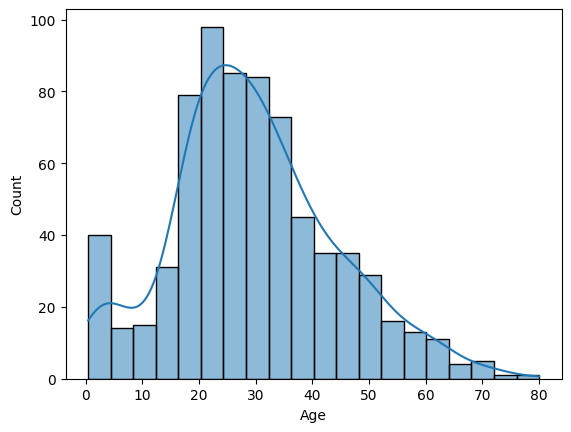

In [207]:
# Histograma de 'Age' antes de imputar datos
sns.histplot(df['Age'].dropna(), kde=True)
plt.show()

In [212]:
impute_age = df['Age'].median()                 # Esta línea calcula la mediana de 'Age'
print('La mediana es ',impute_age, ' años \n')
df.loc[df['Age'].isnull(), 'Age'] = impute_age  # Esta línea hace la imputación

print("Valores nulos DESPUES DE IMPUTAR 'Age': \n")
print(df.isnull().sum()[df.isnull().sum() > 0])

La mediana es  28.0  años 

Valores nulos DESPUES DE IMPUTAR 'Age': 

Cabin       687
Embarked      2
dtype: int64


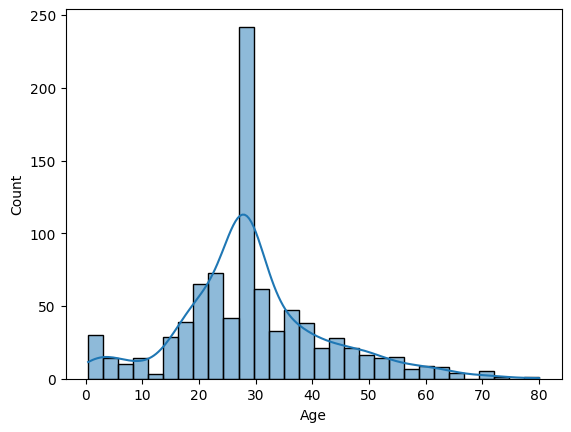

In [213]:
# Histograma de 'Age' después de imputar datos
sns.histplot(df['Age'].dropna(), kde=True)
plt.show()

Imputar `Embarked` con el valor más común (la moda)

In [215]:
print("Valores nulos ANTES DE IMPUTAR 'Embarked':")
print("")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos ANTES DE IMPUTAR 'Embarked':

Cabin       687
Embarked      2
dtype: int64


In [218]:
# Evaluamos cuáles columnas tiene datos faltantes
mode_embarked = df['Embarked'].mode()[0]
df.loc[df['Embarked'].isnull(), 'Embarked'] = mode_embarked

In [219]:
print("Valores nulos DESPUES DE IMPUTAR 'Embarked':")
print("")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos DESPUES DE IMPUTAR 'Embarked':

Cabin    687
dtype: int64


In [220]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**NOTA:** La columna 'Cabin' se eliminará en el siguiente paso por tener demasiados nulos.


## **4. CORRECCIÓN DE ERRORES ESTRUCTURALES**

Estandarización de formatos y categorías

**Paso 4.1:** Estandarización de categorías (en este caso, ya estaban limpias)

**Paso 4.2:** Eliminando columnas no útiles: 'PassengerId', 'Name', 'Ticket', 'Cabin'.

In [221]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [222]:
print("Valores nulos DESPUES DE ELIMINAR 'PassengerId', 'Name', 'Ticket', 'Cabin': \n")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos DESPUES DE ELIMINAR 'PassengerId', 'Name', 'Ticket', 'Cabin': 

Series([], dtype: int64)


**Paso 4.3:** Convirtiendo variables categóricas a numéricas.

 - 'Sex' convertida a 0/1."



In [223]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [224]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


 - 'Embarked' convertida con One-Hot Encoding."

In [225]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Port')
#df = pd.get_dummies(df, columns=['Embarked'], prefix='Port', drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Port_C,Port_Q,Port_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


## **5. TRATAMIENTO DE VALORES ATÍPICOS (OUTLIERS)**

La lógica de outliers depende del objetivo del análisis. Para este caso, no se eliminarán outliers para conservar todos los datos.

## **6. VALIDACIÓN FINAL**

Información final del DataFrame limpio:



In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Port_C    891 non-null    bool   
 8   Port_Q    891 non-null    bool   
 9   Port_S    891 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 51.5 KB


In [228]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Port_C,Port_Q,Port_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


In [229]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Port_C,0
Port_Q,0
Port_S,0


## **Guardar el resultado en un nuevo archivo**

In [230]:
df.to_csv('titanic_cleaned_structured.csv', index=False)

Ver la distribución final de los datos

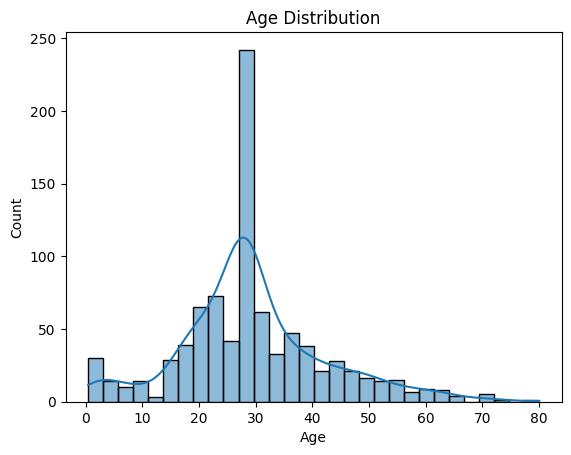

In [231]:
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

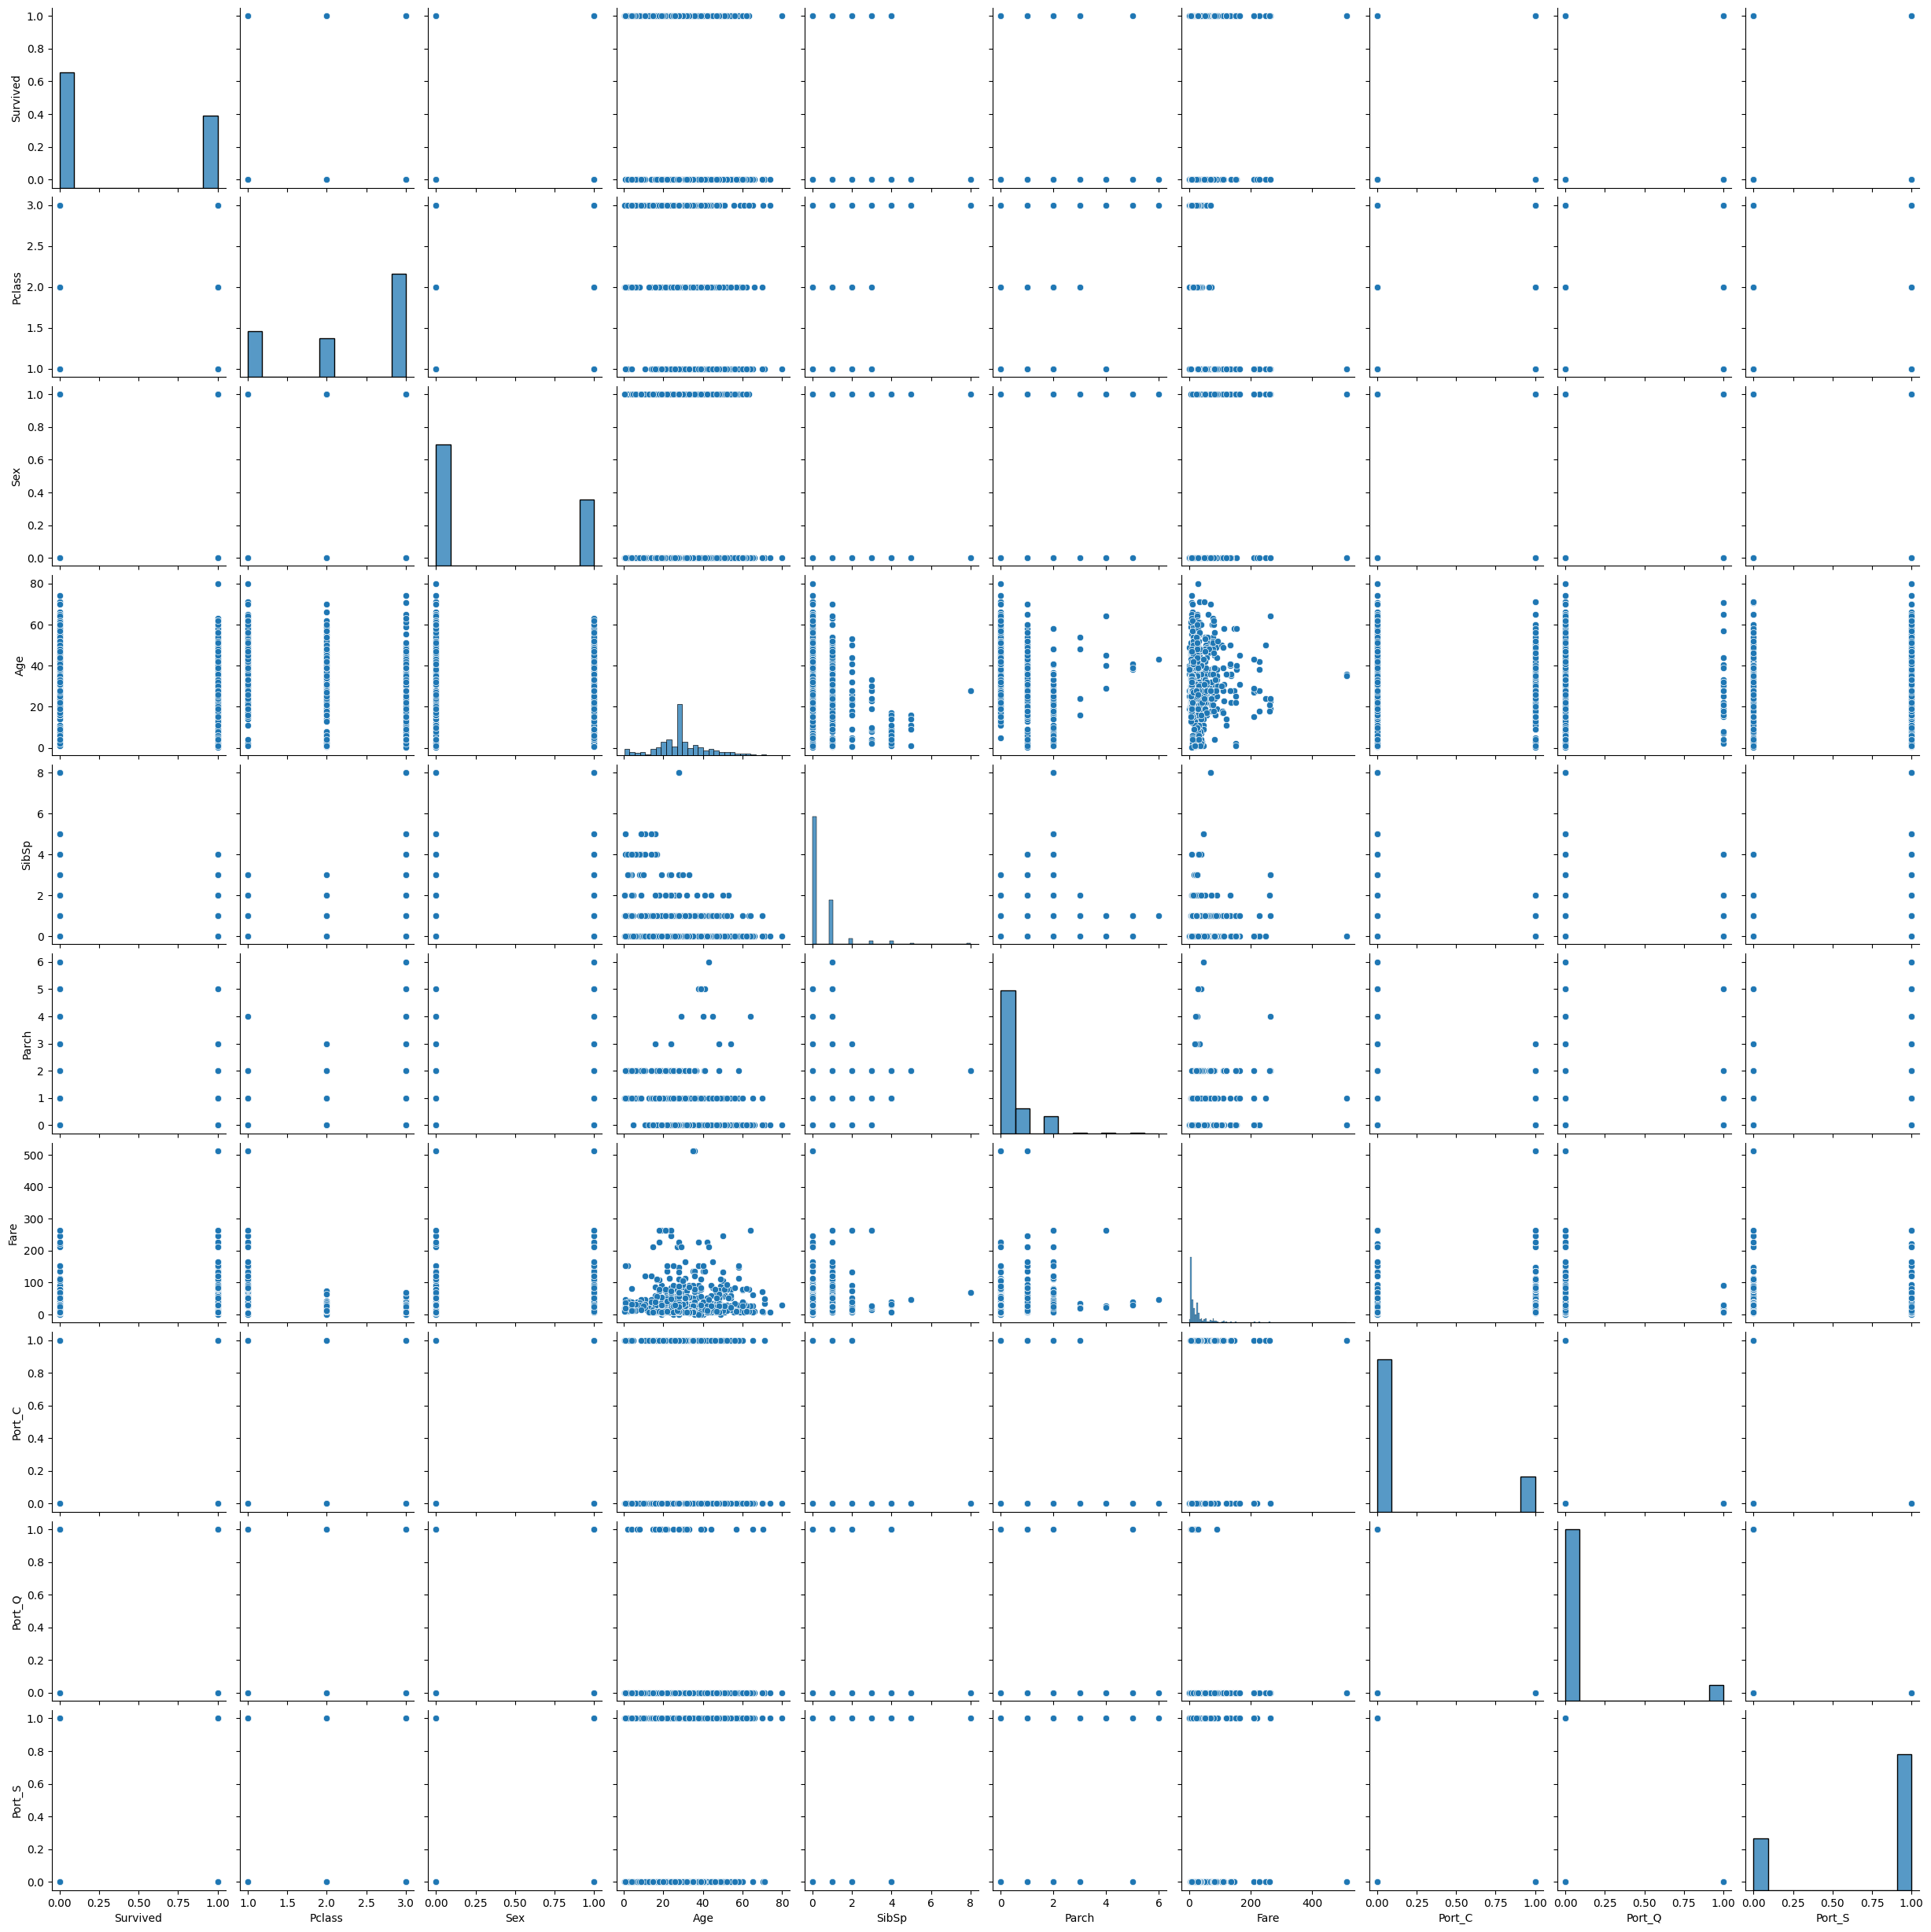

In [232]:
sns.pairplot(df)
plt.show()

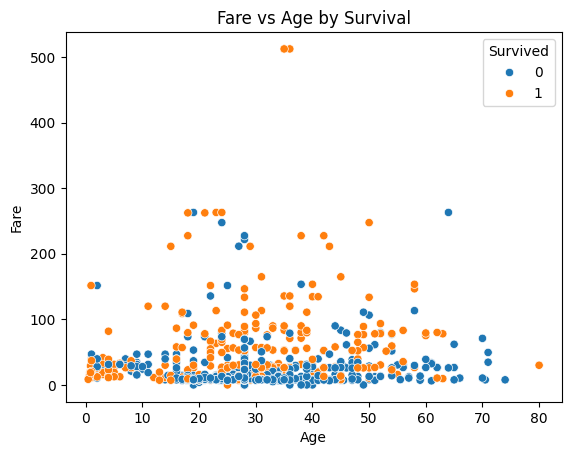

In [236]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Fare vs Age by Survival')
plt.show()